In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
import tensorflow as tf
from tensorflow import keras
import kagglehub
from PIL import Image

In [3]:
mask_dataset_path = kagglehub.dataset_download("ashishjangra27/face-mask-12k-images-dataset")
print(f"Mask dataset downloaded to: {mask_dataset_path}")

for root, dirs, files in os.walk(mask_dataset_path):
    level = root.replace(mask_dataset_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    if level < 2:
        for f in files[:2]:
            print(f"{subindent}{f}")

100%|██████████| 330M/330M [00:05<00:00, 62.3MB/s]

Extracting files...


Mask dataset downloaded to: /root/.cache/kagglehub/datasets/ashishjangra27/face-mask-12k-images-dataset/versions/1
1/
    Face Mask Dataset/
        Test/
            WithMask/
            WithoutMask/
        Train/
            WithMask/
            WithoutMask/
        Validation/
            WithMask/
            WithoutMask/


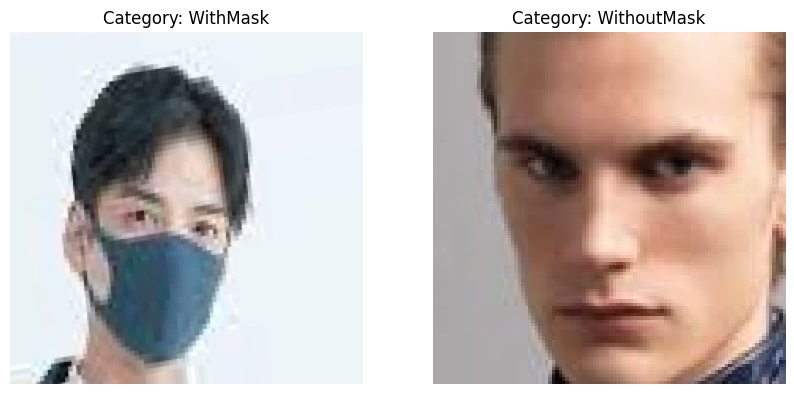

In [4]:
train_dir = os.path.join(mask_dataset_path, 'Face Mask Dataset/Train')
categories = ['WithMask', 'WithoutMask']

plt.figure(figsize=(10, 5))
for i, cat in enumerate(categories):
    cat_path = os.path.join(train_dir, cat)
    img_name = os.listdir(cat_path)[0]
    img_path = os.path.join(cat_path, img_name)

    img = Image.open(img_path)
    plt.subplot(1, 2, i+1)
    plt.imshow(img)
    plt.title(f"Category: {cat}")
    plt.axis('off')

plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import AveragePooling2D, Dropout, Flatten, Dense, Input
from tensorflow.keras.models import Model
import os

def build_and_train(dataset_path, epochs=5, fine_tune_epochs=5, batch_size=32):
    train_dir = os.path.join(dataset_path, 'Face Mask Dataset/Train')
    val_dir = os.path.join(dataset_path, 'Face Mask Dataset/Validation')

    # MobileNetV2 requires preprocess_input (scales to [-1, 1]), NOT rescale=1./255
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=20,
        horizontal_flip=True,
        zoom_range=0.15,
        brightness_range=[0.8, 1.2],
        shear_range=0.1,
    )
    val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    train_gen = train_datagen.flow_from_directory(train_dir, target_size=(224, 224), batch_size=batch_size, class_mode='categorical')
    val_gen = val_datagen.flow_from_directory(val_dir, target_size=(224, 224), batch_size=batch_size, class_mode='categorical')

    base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))
    x = AveragePooling2D(pool_size=(7, 7))(base.output)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(2, activation='sigmoid')(x)

    model = Model(inputs=base.input, outputs=outputs)

    # Phase 1: train only the custom head
    for layer in base.layers:
        layer.trainable = False

    model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), metrics=['accuracy'])
    print("Phase 1: training custom head only")
    model.fit(train_gen, validation_data=val_gen, epochs=epochs)

    # Phase 2: fine-tune top 30 layers of MobileNetV2 with a lower learning rate
    for layer in base.layers[-30:]:
        layer.trainable = True

    model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), metrics=['accuracy'])
    print("Phase 2: fine-tuning top 30 MobileNetV2 layers")
    model.fit(train_gen, validation_data=val_gen, epochs=fine_tune_epochs)

    model.save('my_model.keras')
    model.save('visibility_model.h5')
    return model

In [6]:
model_vis = build_and_train(mask_dataset_path, epochs=2)

Found 10000 images belonging to 2 classes.
Found 800 images belonging to 2 classes.


/tmp/ipykernel_1031/917882338.py:17: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 555s 2s/step - accuracy: 0.9296 - loss: 0.1821 - val_accuracy: 0.9837 - val_loss: 0.0515
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 532s 2s/step - accuracy: 0.9789 - loss: 0.0621 - val_accuracy: 0.9900 - val_loss: 0.0399


In [ ]:
model_vis.save('my_model.keras')

In [ ]:
import os

app_exists = os.path.exists("app.py")
req_exists = os.path.exists("requirements.txt")
model_exists = os.path.exists("my_model.keras")

print(f"app.py          : {'✅ found' if app_exists else '❌ missing'}")
print(f"requirements.txt: {'✅ found' if req_exists else '❌ missing'}")
print(f"my_model.keras  : {'✅ found' if model_exists else '❌ missing'}")
print()
print("Run the Streamlit app:")
print("  pip install -r requirements.txt")
print("  streamlit run app.py")

## Export — Streamlit App

The cells below write `app.py` and `requirements.txt` directly into this folder so the app is ready to run with:

```bash
streamlit run app.py
```

In [ ]:
# ── Replace with the path to any face image ────────────────────────
TEST_IMAGE = "path/to/your/test_face.jpg"

if os.path.exists(TEST_IMAGE):
    run_pipeline(TEST_IMAGE)
else:
    print("Set TEST_IMAGE to an actual file path and re-run this cell.")

### Quick demo

To test the full pipeline, drop a face image into the cell below.  
To test authorization, first copy at least one reference photo into `authorized_faces/` — name the file after the person (e.g. `john.jpg`).

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

def check_visibility(img: Image.Image):
    """Stage 1 — returns (label, confidence)."""
    arr = np.array(img.convert("RGB").resize((224, 224)), dtype=np.float32)
    arr = mobilenet_preprocess(arr)  # scales to [-1, 1] as MobileNetV2 expects
    pred = visibility_model.predict(np.expand_dims(arr, 0), verbose=0)[0]
    idx = int(np.argmax(pred))
    return VISIBILITY_LABELS[idx], float(pred[idx])


def check_authorization(img: Image.Image, authorized_dir: str = AUTHORIZED_DIR):
    """Stage 2 — compare against registered faces using VGG-Face embeddings.
    Returns (label, confidence_0_to_1).
    """
    refs = [f for f in os.listdir(authorized_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    if not refs:
        return "No authorized faces registered", 0.0

    # Save probe image to a temp file so DeepFace can read it
    with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as tmp:
        img.convert("RGB").save(tmp.name)
        probe_path = tmp.name

    best_distance, best_name, best_verified = float("inf"), None, False
    best_threshold = 0.4
    try:
        for fname in refs:
            ref_path = os.path.join(authorized_dir, fname)
            try:
                result = DeepFace.verify(
                    img1_path=probe_path,
                    img2_path=ref_path,
                    model_name="VGG-Face",
                    enforce_detection=False,
                    silent=True,
                )
                if result["distance"] < best_distance:
                    best_distance = result["distance"]
                    best_name = os.path.splitext(fname)[0]
                    best_verified = result["verified"]
                    best_threshold = result["threshold"]
            except Exception:
                continue
    finally:
        os.unlink(probe_path)

    if best_verified:
        confidence = max(0.0, 1.0 - best_distance / best_threshold)
        return f"Authorized — {best_name}", confidence
    return "Unauthorized", 0.0


def run_pipeline(image_path: str):
    """Full two-stage pipeline. Prints a structured report."""
    img = Image.open(image_path)

    vis_label, vis_conf = check_visibility(img)
    print(f"Stage 1 | {vis_label:10s} | confidence: {vis_conf:.2%}")

    if vis_label == "Covered":
        print("Stage 2 | SKIPPED — face is covered")
        return

    auth_label, auth_conf = check_authorization(img)
    tag = "✅" if "Authorized" in auth_label else "❌"
    print(f"Stage 2 | {tag} {auth_label} | confidence: {auth_conf:.2%}")

print("Pipeline functions defined.")

In [ ]:
import os, shutil, tempfile
import numpy as np
from PIL import Image
import tensorflow as tf
from deepface import DeepFace

# ── Load the visibility model saved in Stage 1 ─────────────────────
visibility_model = tf.keras.models.load_model("my_model.keras")

# Training used flow_from_directory with folders [WithMask, WithoutMask]
# Keras sorts alphabetically → WithMask=0, WithoutMask=1
VISIBILITY_LABELS = {0: "Covered", 1: "Uncovered"}

AUTHORIZED_DIR = "authorized_faces"
os.makedirs(AUTHORIZED_DIR, exist_ok=True)
print(f"Authorized faces directory: {os.path.abspath(AUTHORIZED_DIR)}")
print(f"Add reference images of authorized people to this folder before running Stage 2.")

In [ ]:
# Install DeepFace if not already present
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "deepface", "-q"], check=True)
print("DeepFace ready")

## Stage 2 — Face Authorization

With the visibility model in place we now add a second stage:

| Condition | Action |
|---|---|
| Face is **covered** | Reject immediately — cannot identify |
| Face is **uncovered** | Run authorization check |
| Authorization **passes** | ✅ Authorized |
| Authorization **fails** | ❌ Unauthorized |

We use **DeepFace** (VGG-Face backbone) for face verification.  
Authorized individuals are stored as reference photos in `authorized_faces/`.  
When a new face arrives, DeepFace computes the embedding distance against every reference image — if the best distance is below the model threshold the person is authorized.